# Project 1 — Step 3: Risk Prediction Model

Goal: predict whether a patient is at **high** or **low emergency visit risk**
using the variables available in our own hospital dataset (age, BMI, glucose,
BP, comorbidities, admission history, etc.)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, roc_curve, roc_auc_score, classification_report)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)

FILE_PATH = "hospital_patient_dataset.xlsx"
df = pd.read_excel(FILE_PATH, sheet_name="Patient_Dataset")
df.shape

(250, 25)

## 1. Feature engineering

In [3]:
df["N_Comorbidities"] = df["Comorbidities"].apply(
    lambda x: 0 if pd.isna(x) or str(x).strip().lower() == "none" else len(str(x).split(","))
)
df["Is_Emergency"] = (df["Admission_Type"] == "Emergency").astype(int)

FEATURE_COLS = [
    "Age", "BMI", "Blood_Glucose_mgdL", "Systolic_BP", "Diastolic_BP", "Cholesterol_mgdL",
    "N_Comorbidities", "Is_Emergency", "Previous_Admissions", "Previous_Visits_1Yr", "Medications_Count"
]
TARGET_COL = "Emergency_Visit_Risk"

X = df[FEATURE_COLS].copy()
y = (df[TARGET_COL] == "High").astype(int)  # 1 = High risk, 0 = Low risk

print(y.value_counts())
X.head()

Emergency_Visit_Risk
0    212
1     38
Name: count, dtype: int64


,Age,BMI,Blood_Glucose_mgdL,Systolic_BP,Diastolic_BP,Cholesterol_mgdL,N_Comorbidities,Is_Emergency,Previous_Admissions,Previous_Visits_1Yr,Medications_Count
0,23,25.4,92,126,75,198,1,1,2,1,1
1,7,24.3,85,80,52,131,0,0,0,0,1
2,10,21.8,79,102,70,133,1,0,1,2,6
3,7,16.7,90,119,72,160,0,0,1,2,0
4,25,29.6,98,117,71,199,0,0,0,1,1


## 2. Train/test split and scaling

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

print("Train size:", X_train.shape, " Test size:", X_test.shape)

Train size: (200, 11)  Test size: (50, 11)


## 3. Train the model (Logistic Regression)

In [5]:
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_s, y_train)

y_pred = clf.predict(X_test_s)
y_proba = clf.predict_proba(X_test_s)[:, 1]

print("Accuracy: ", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall:   ", round(recall_score(y_test, y_pred), 3))
print("F1 score: ", round(f1_score(y_test, y_pred), 3))
print("ROC-AUC:  ", round(roc_auc_score(y_test, y_proba), 3))
print()
print(classification_report(y_test, y_pred, target_names=["Low risk", "High risk"]))

Accuracy:  0.96
Precision: 0.875
Recall:    0.875
F1 score:  0.875
ROC-AUC:   0.997

              precision    recall  f1-score   support

    Low risk       0.98      0.98      0.98        42
   High risk       0.88      0.88      0.88         8

    accuracy                           0.96        50
   macro avg       0.93      0.93      0.93        50
weighted avg       0.96      0.96      0.96        50



## 4. Confusion matrix

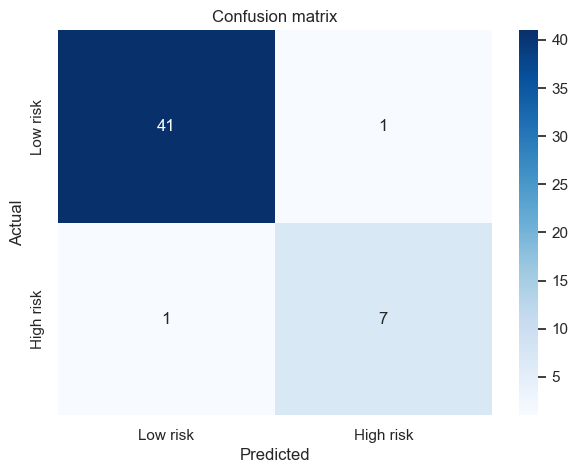

In [6]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low risk", "High risk"], yticklabels=["Low risk", "High risk"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix")
plt.show()

## 5. ROC curve

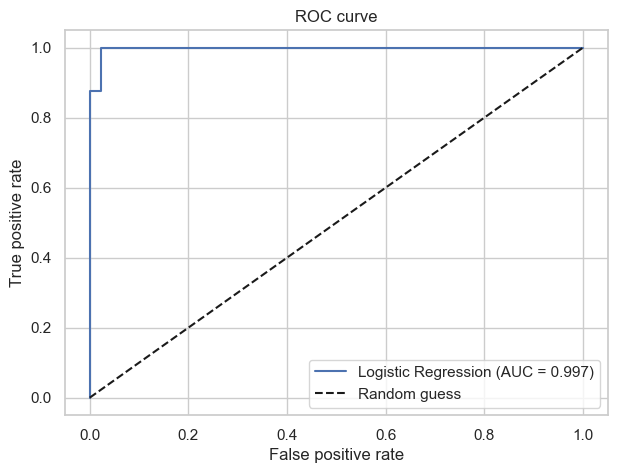

In [7]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_proba):.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve")
plt.legend()
plt.show()

## 6. Which features matter most?

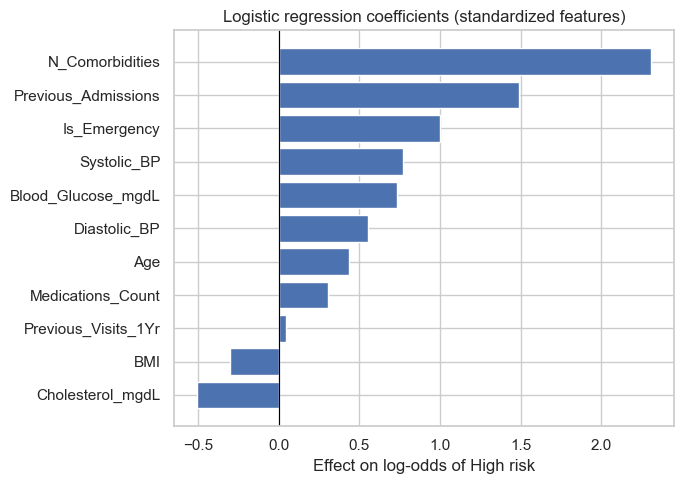

,feature,coefficient
5,Cholesterol_mgdL,-0.508197
1,BMI,-0.300600
9,Previous_Visits_1Yr,0.043831
10,Medications_Count,0.302850
0,Age,0.435920
4,Diastolic_BP,0.556597
2,Blood_Glucose_mgdL,0.731621
3,Systolic_BP,0.768821
7,Is_Emergency,0.997370
8,Previous_Admissions,1.489281


In [8]:
coef_df = pd.DataFrame({"feature": FEATURE_COLS, "coefficient": clf.coef_[0]})
coef_df = coef_df.sort_values("coefficient")

plt.figure(figsize=(7, 5))
plt.barh(coef_df["feature"], coef_df["coefficient"])
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Logistic regression coefficients (standardized features)")
plt.xlabel("Effect on log-odds of High risk")
plt.tight_layout()
plt.show()

coef_df

## 7. Compare with a Random Forest (bonus model)

Logistic regression assumes a linear relationship. A Random Forest can capture
non-linear patterns — worth comparing accuracy.

Random Forest accuracy: 0.96
Random Forest ROC-AUC:  1.0


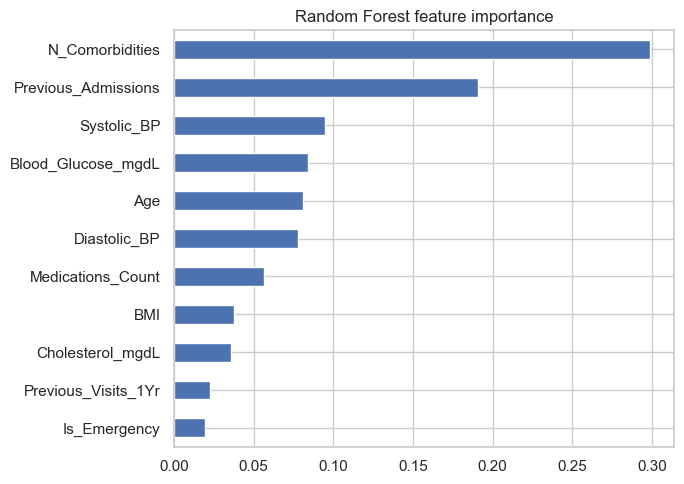

In [9]:
rf = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)
rf.fit(X_train, y_train)  # tree models don't need scaling
rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print("Random Forest accuracy:", round(accuracy_score(y_test, rf_pred), 3))
print("Random Forest ROC-AUC: ", round(roc_auc_score(y_test, rf_proba), 3))

importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values()
importances.plot(kind="barh", figsize=(7, 5), title="Random Forest feature importance")
plt.tight_layout()
plt.show()

## 8. Predict risk for a new patient

In [10]:
def predict_risk(age, bmi, glucose, systolic_bp, diastolic_bp, cholesterol,
                  n_comorbidities, is_emergency, prev_admissions, prev_visits, medications):
    row = pd.DataFrame([[age, bmi, glucose, systolic_bp, diastolic_bp, cholesterol,
                          n_comorbidities, is_emergency, prev_admissions, prev_visits, medications]],
                        columns=FEATURE_COLS)
    row_s = scaler.transform(row)
    proba = clf.predict_proba(row_s)[0, 1]
    label = "High" if proba >= 0.5 else "Low"
    return label, round(proba, 3)

# Example: a 60-year-old with 2 comorbidities admitted as an emergency
predict_risk(age=60, bmi=29, glucose=140, systolic_bp=150, diastolic_bp=95,
             cholesterol=220, n_comorbidities=2, is_emergency=1,
             prev_admissions=2, prev_visits=3, medications=3)

('High', np.float64(1.0))